ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

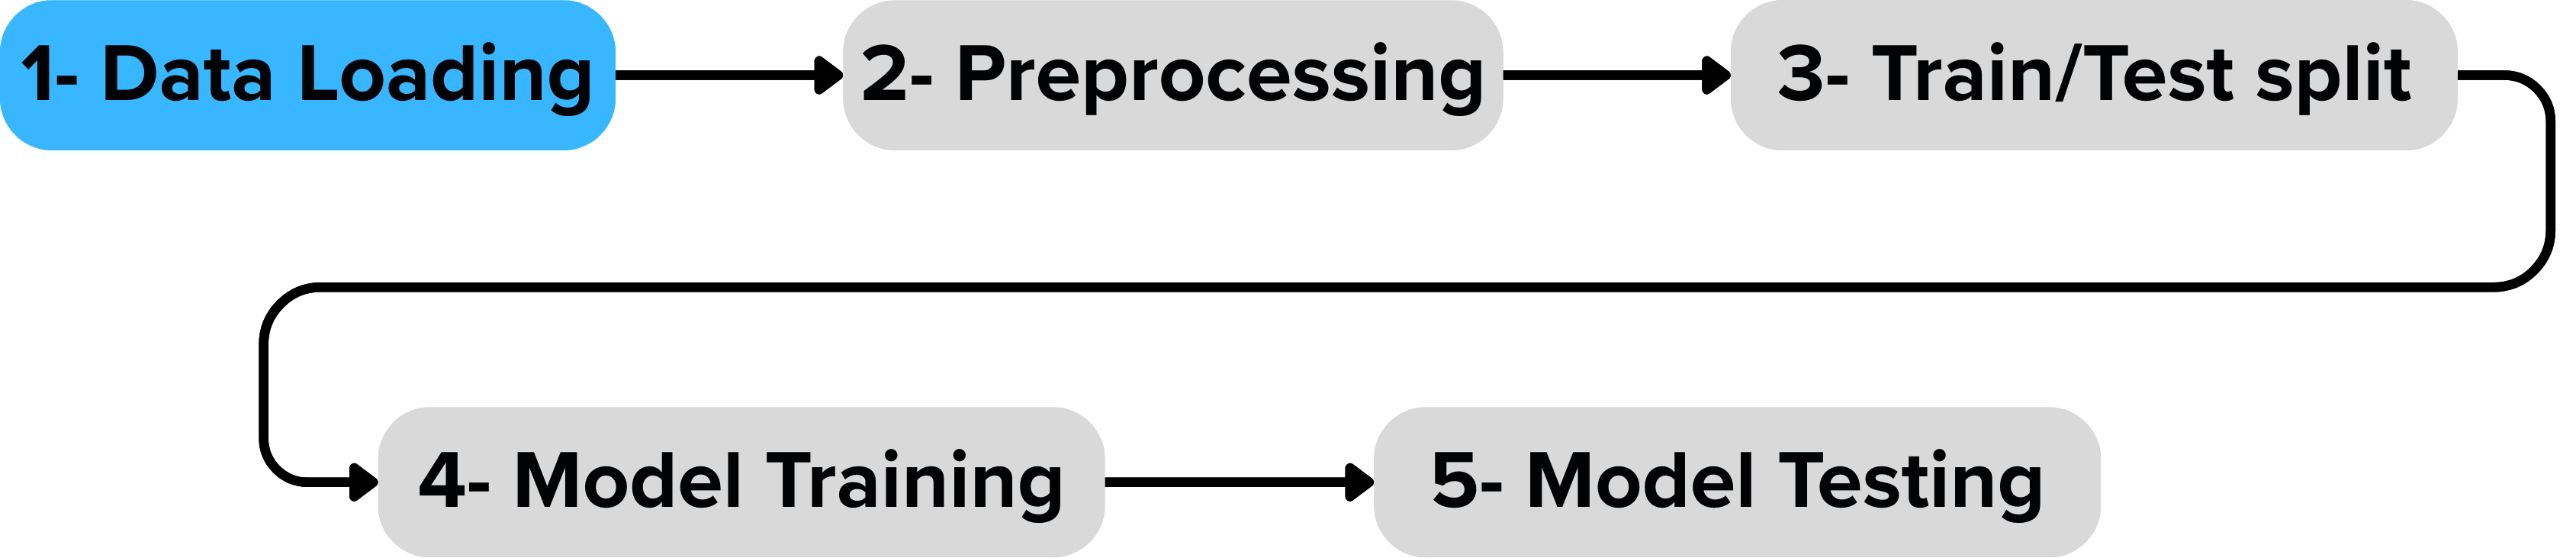

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [6]:
# Load Dataset

df = pd.read_csv(r"C:\Users\haido\Desktop\ARTI308-Lab3\Data\car_price_prediction_with_missing.csv")

# Display first 5 rows
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


### Check Missing Values

In [7]:
# Check all values
print(df.isna())

      Car ID  Brand   Year  Engine Size  Fuel Type  Transmission  Mileage  \
0      False  False  False        False      False         False    False   
1      False  False  False        False      False         False    False   
2      False  False  False        False      False         False    False   
3      False  False  False        False      False         False    False   
4      False  False  False        False      False         False    False   
...      ...    ...    ...          ...        ...           ...      ...   
2495   False  False  False        False      False         False    False   
2496   False  False  False        False      False         False    False   
2497    True   True   True         True       True          True     True   
2498   False  False  False        False      False         False    False   
2499   False  False  False        False      False         False    False   

      Condition  Price  Model  
0         False  False  False  
1         F

In [8]:
print(df.isna().sum())

Car ID          250
Brand           250
Year            250
Engine Size     250
Fuel Type       250
Transmission    250
Mileage         250
Condition       250
Price           250
Model           250
dtype: int64


### Check duplicate rows

In [9]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

44      True
56      True
93      True
96      True
111     True
        ... 
2442    True
2472    True
2480    True
2487    True
2497    True
Length: 249, dtype: bool

### No. of rows and columns

In [10]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (2500, 10) 

number of rows:  2500
number of columns:  10


### Data type of columns

In [11]:
# viewing the data types of columns
df.dtypes

Car ID          float64
Brand               str
Year            float64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage         float64
Condition           str
Price           float64
Model               str
dtype: object

In [25]:
df['Year'] = pd.to_datetime(df['Year'])

df.dtypes

Car ID                 float64
Brand                      str
Year            datetime64[ns]
Engine Size            float64
Fuel Type                  str
Transmission               str
Mileage                float64
Condition                  str
Price                  float64
Model                      str
dtype: object

### Descriptive summary Statistics

In [14]:
# Statistical summary
df.describe(include='all')

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
count,2250.000000,2250,2250.000000,2250.000000,2250,2250,2250.000000,2250,2250.000000,2250
unique,NaN,7,NaN,NaN,4,2,NaN,3,NaN,28
top,NaN,Toyota,NaN,NaN,Diesel,Manual,NaN,Used,NaN,Corolla
freq,NaN,346,NaN,NaN,587,1184,NaN,769,NaN,97
mean,1251.243556,NaN,2011.577778,3.485467,NaN,NaN,150236.178222,NaN,52506.874391,NaN
std,725.637358,NaN,6.980468,1.427690,NaN,NaN,88150.746556,NaN,27232.417079,NaN
min,1.000000,NaN,2000.000000,1.000000,NaN,NaN,15.000000,NaN,5011.270000,NaN
25%,627.250000,NaN,2005.000000,2.300000,NaN,NaN,71178.500000,NaN,28985.052500,NaN
50%,1249.500000,NaN,2012.000000,3.450000,NaN,NaN,149762.000000,NaN,53485.240000,NaN
75%,1875.250000,NaN,2018.000000,4.700000,NaN,NaN,226299.000000,NaN,75560.340000,NaN


### Univariate Analysis

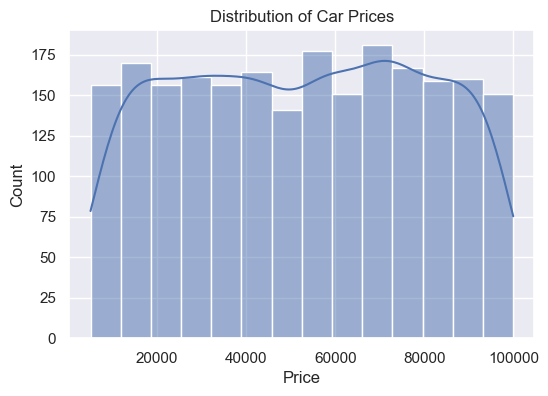

In [21]:
plt.figure(figsize=(6,4))
sns.histplot(df['Price'], kde=True)
plt.title("Distribution of Car Prices")
plt.show()

Some features in the dataset contain missing values. This analysis helps
identify which columns have incomplete data.


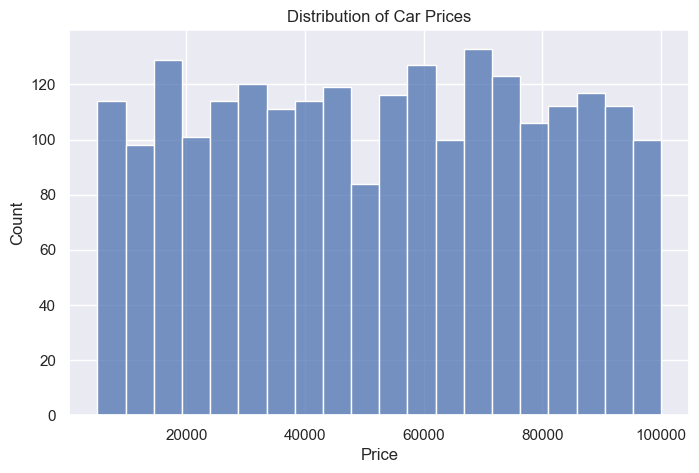

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20)
plt.title("Distribution of Car Prices")
plt.show()

## Bivariate Analysis

### Selling Price by Brand

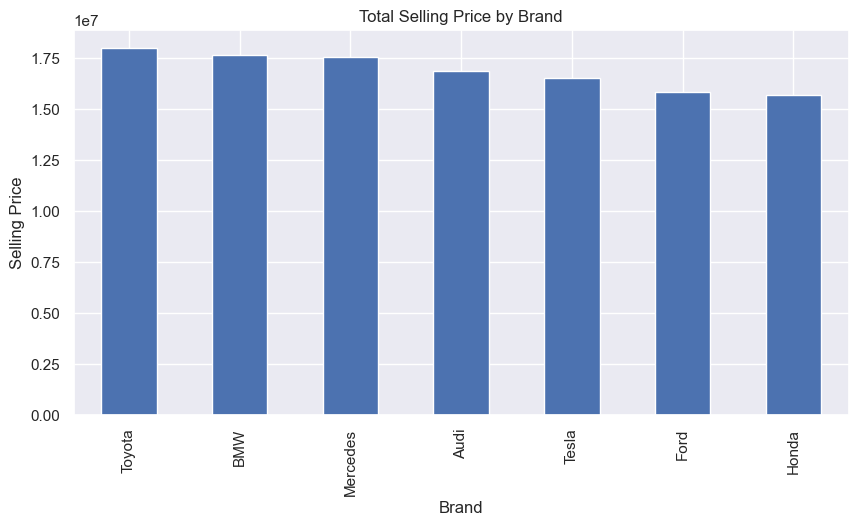

In [31]:
Price_Brand = df.groupby('Brand')['Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
Price_Brand.plot(kind='bar')
plt.title("Total Selling Price by Brand")
plt.ylabel("Selling Price")
plt.show()


### Mileage vs Selling Price Relationship

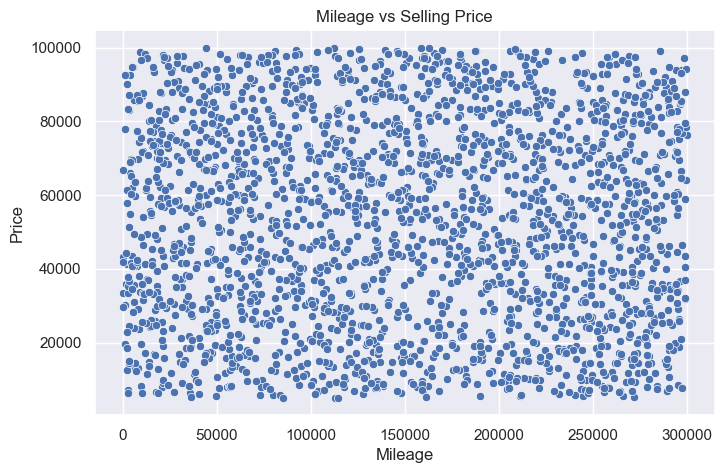

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Mileage', y='Price', data=df)
plt.title("Mileage vs Selling Price")
plt.show()

### Correlation Matrix

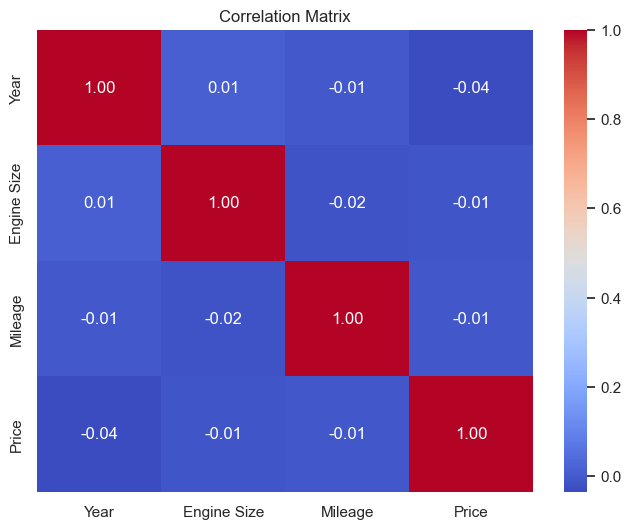

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Year', 'Engine Size', 'Mileage', 'Price']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.